<a href="https://colab.research.google.com/github/AnanthSundarrajan/Heart-disease-prediction-Streamlit/blob/main/HDP_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Disease Prediction - Source code

**Background & Introduction**
The significance of this project lies in addressing heart disease, the principal cause of mortality globally. Unlike acute trauma, such as bone fractures or contusions, heart disease progresses slowly and is often referred to as the "Silent Killer." Optimal management necessitates early detection and intervention. Current direct diagnostic methods, such as angiograms, are both costly and subject patients to potentially unnecessary radiation exposure. This project proposes utilizing non-invasive measures, specifically a person's biometric markers and preliminary tests, including Electrocardiogram (ECG) results, fasting blood sugar levels, and reported chest pain, to predict the probability of underlying heart disease.
Should an individual be predicted to have underlying heart disease, more advanced diagnostics, including both invasive procedures and medical imaging, can then be appropriately performed. Furthermore, this project aims to minimize unnecessary medical interventions for individuals who are not determined to be at risk for cardiac disease.

**Research Question**
Can we predict the likelihood of a person having heart disease based on their personal and medical parameters?

**Data Sources**
Heart Failure Prediction Dataset from Kaggle (https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)

**Methodology**
CRISP-DM

## Step 1 - Load Data set

In [88]:
#Step 1.1 - Download the data set "heart-failure-prediction" from Kaggle (https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction) and load the dataset into a pandas dataframe
import kagglehub
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

import pandas as pd
import os

#Step 1.2 - Load the dataset into a pandas DataFrame
df = pd.read_csv(os.path.join(path, 'heart.csv'))

#Step 1.3 - Load all libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Using Colab cache for faster access to the 'heart-failure-prediction' dataset.


## Step 2 - Exploratory data analysis

In [89]:
#Step 2.1 - Understand the general information about the DataFrame
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


In [90]:
#Step 2.2 - Check for missing values
df.isnull().sum()


,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [91]:
#Step 2.3 - Check for duplicate values

if df.duplicated().sum() > 0:
    print("Duplicate Rows:")
    display(df[df.duplicated(keep=False)])
else:
    print("No duplicate rows found.")

No duplicate rows found.


Numerical features identified for outlier checking: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


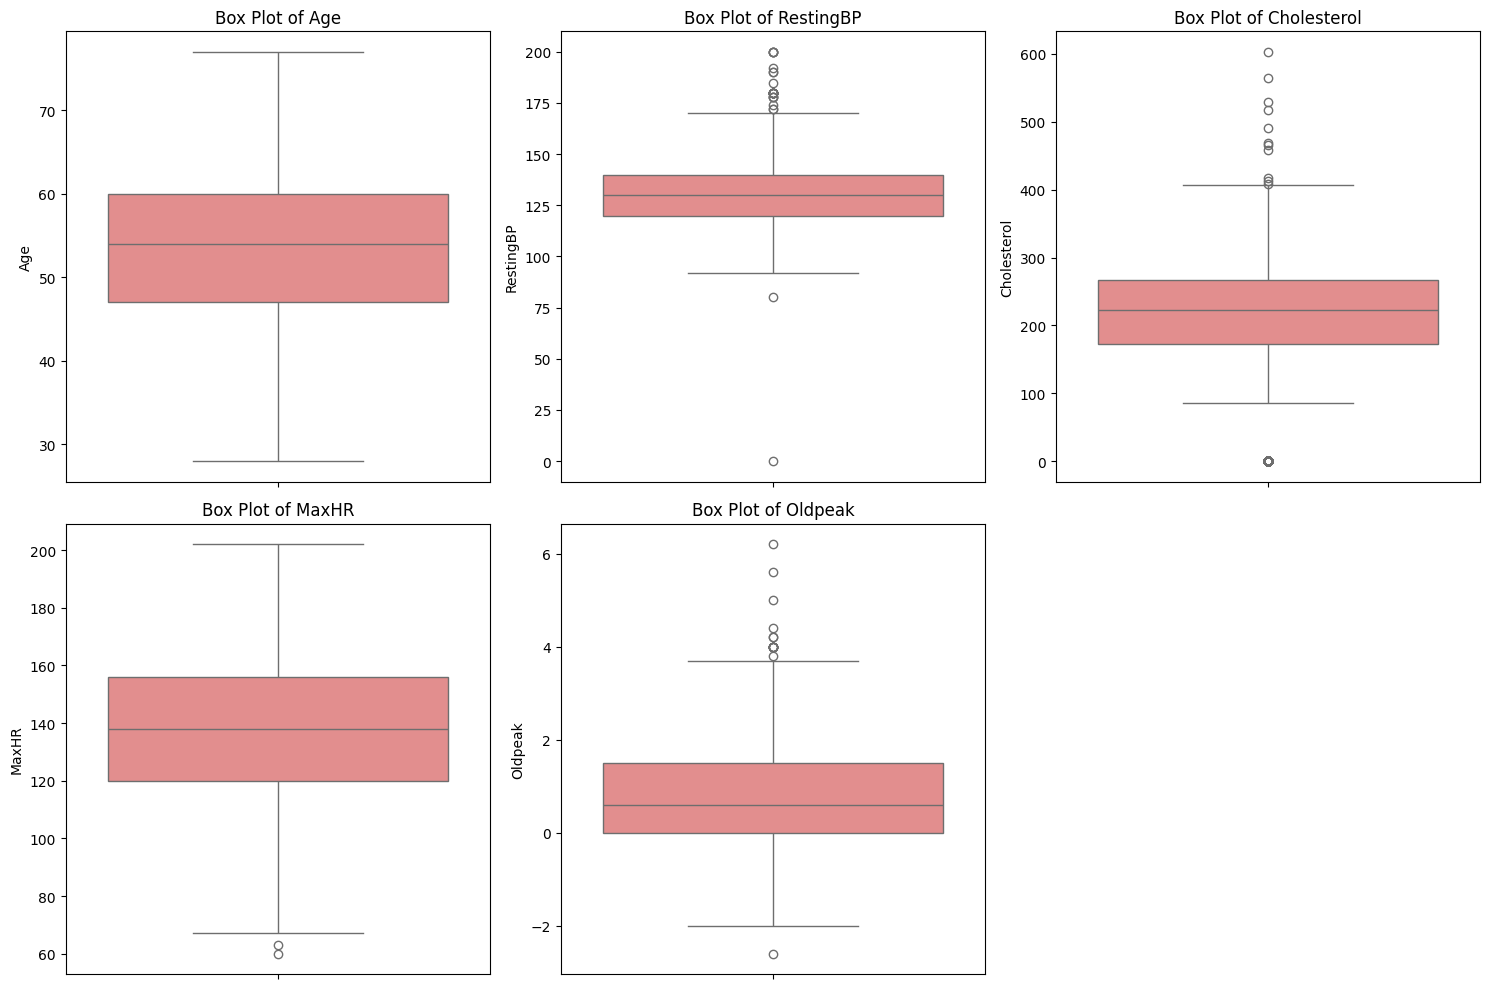

Box plots for numerical features displayed to visualize outliers.

--- Feature: Age ---
Q1 (25th percentile): 47.00
Q3 (75th percentile): 60.00
IQR: 13.00
Lower Bound: 27.50
Upper Bound: 79.50
Number of Outliers: 0

--- Feature: RestingBP ---
Q1 (25th percentile): 120.00
Q3 (75th percentile): 140.00
IQR: 20.00
Lower Bound: 90.00
Upper Bound: 170.00
Number of Outliers: 28

--- Feature: Cholesterol ---
Q1 (25th percentile): 173.25
Q3 (75th percentile): 267.00
IQR: 93.75
Lower Bound: 32.62
Upper Bound: 407.62
Number of Outliers: 183

--- Feature: MaxHR ---
Q1 (25th percentile): 120.00
Q3 (75th percentile): 156.00
IQR: 36.00
Lower Bound: 66.00
Upper Bound: 210.00
Number of Outliers: 2

--- Feature: Oldpeak ---
Q1 (25th percentile): 0.00
Q3 (75th percentile): 1.50
IQR: 1.50
Lower Bound: -2.25
Upper Bound: 3.75
Number of Outliers: 16


In [92]:
#Step 2.4 - For each numerical feature, calculate the Interquartile Range (IQR) and identify potential outliers based on the 1.5*IQR rule and visualize them

numerical_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
print(f"Numerical features identified for outlier checking: {numerical_features}")
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

print("Box plots for numerical features displayed to visualize outliers.")

outliers_data = {}

for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers = outliers.shape[0]

    outliers_data[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Number of Outliers': num_outliers
    }

    print(f"\n--- Feature: {col} ---")
    print(f"Q1 (25th percentile): {Q1:.2f}")
    print(f"Q3 (75th percentile): {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Number of Outliers: {num_outliers}")

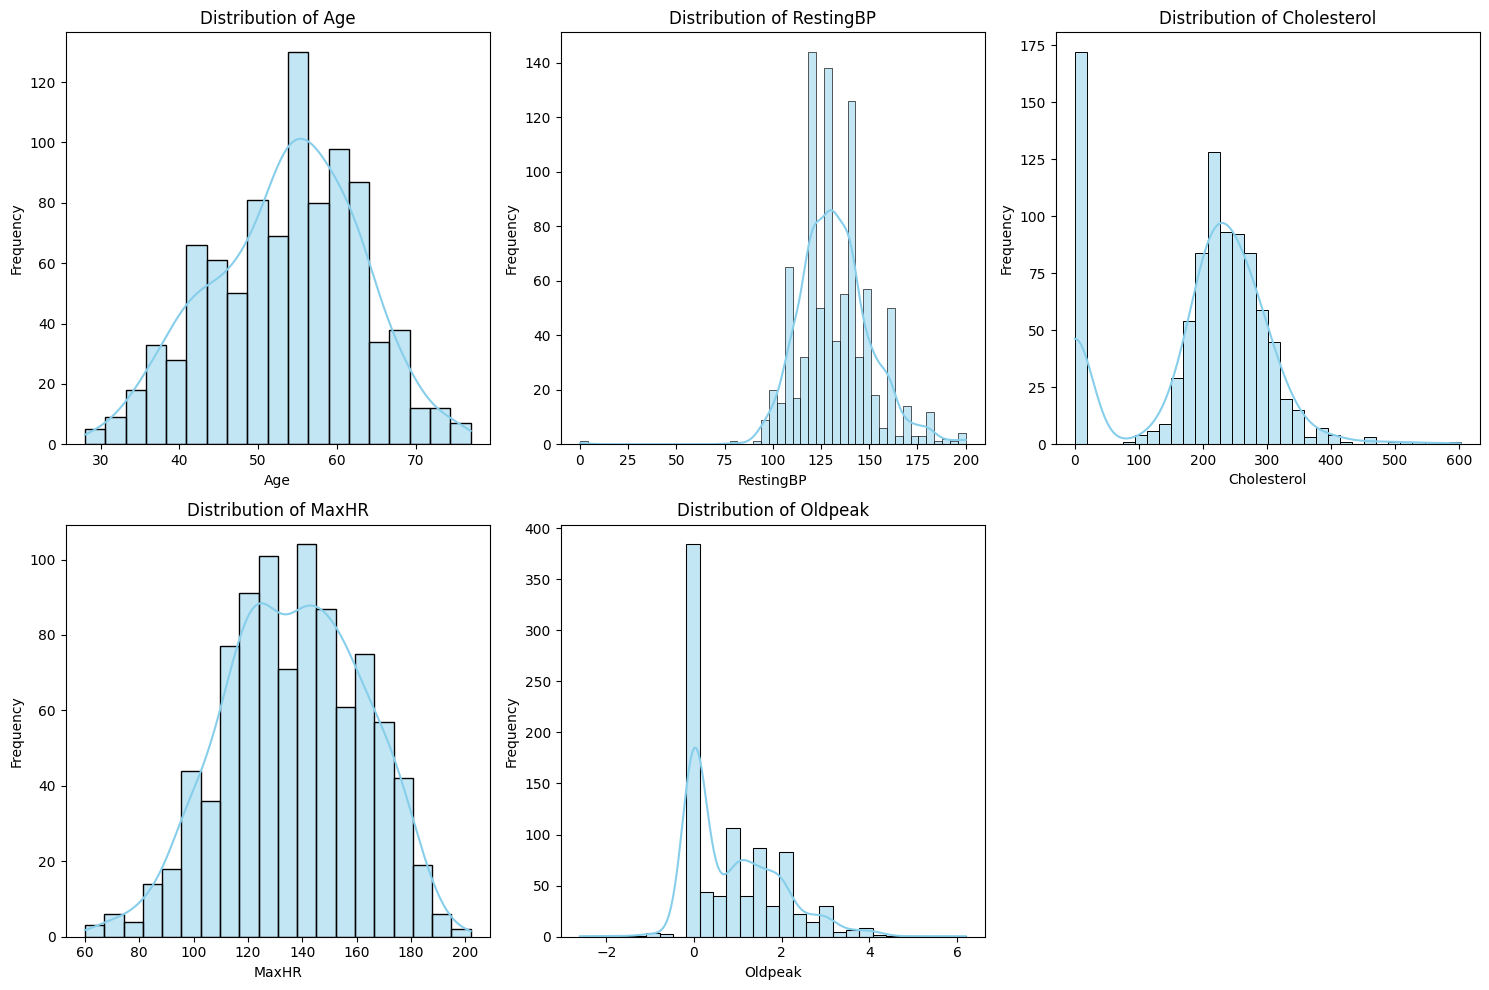

Visualized distributions of numerical features.


In [93]:
#Step 2.5 - Visualize the various numerical features using "matplotlib" and "seaborn" libraries

numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
print("Visualized distributions of numerical features.")

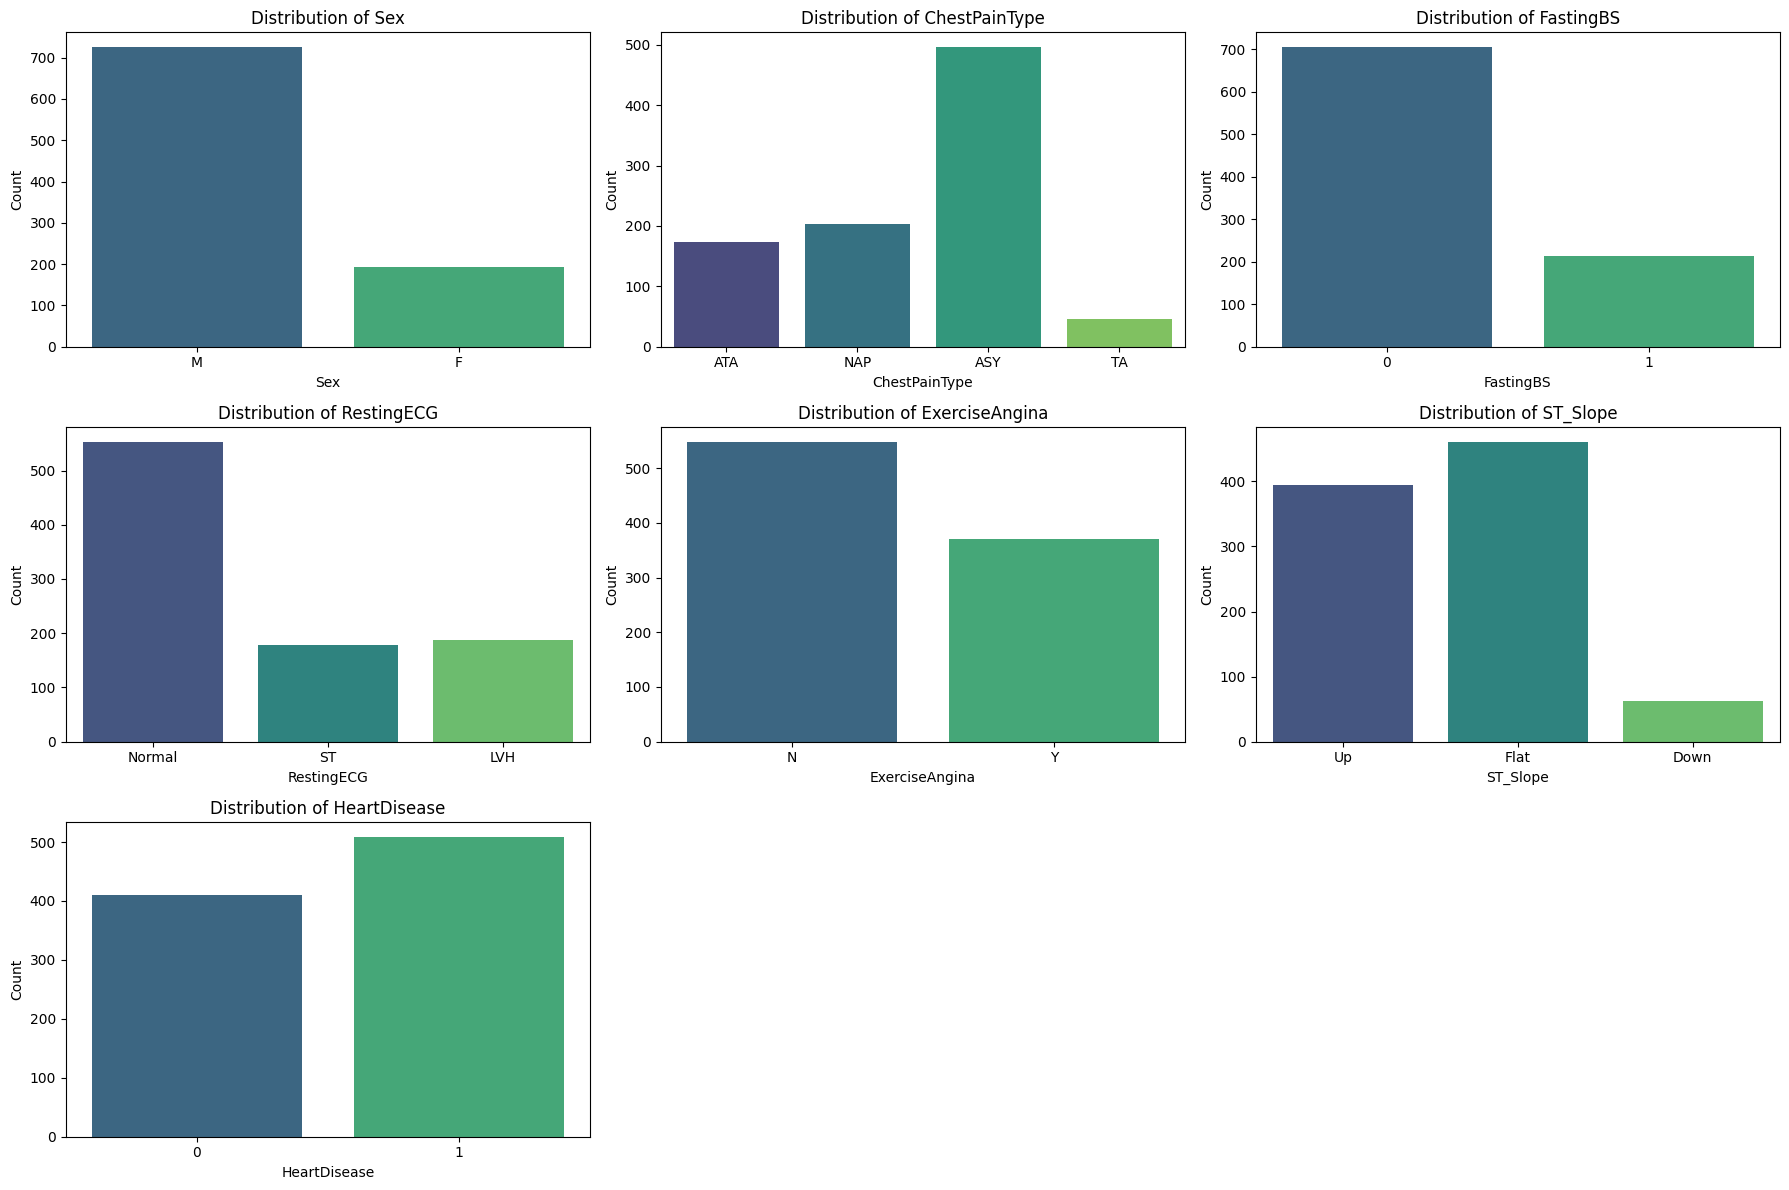

Visualized distributions of categorical features.


In [94]:
#Step 2.6 - Visualize the various categorical features

categorical_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=df[col], hue=df[col], palette='viridis', legend=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()
print("Visualized distributions of categorical features.")

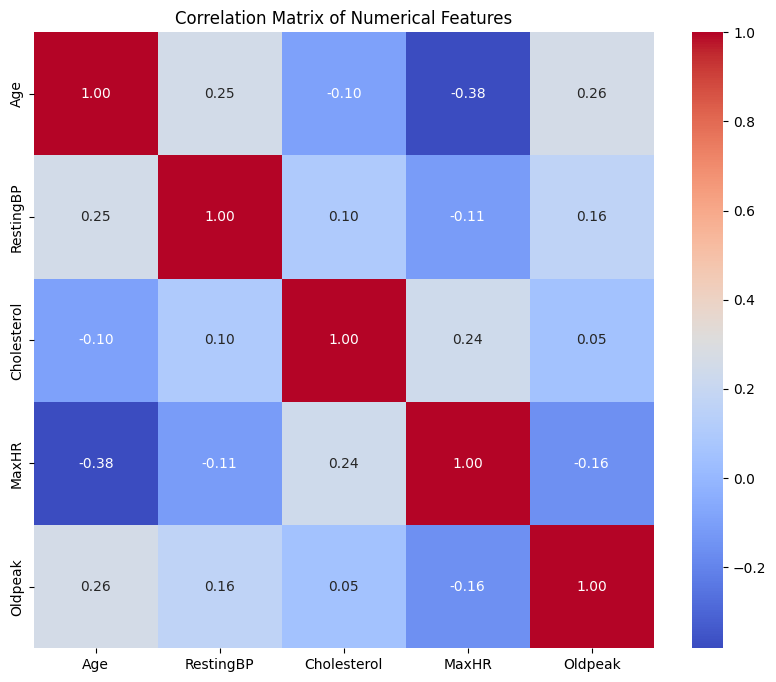

Visualized the correlation matrix of numerical features.


In [95]:
#Step 2.7 - Analyze the correlation between numerical features using the "Correlation Matrix"

numerical_df = df[numerical_cols]
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()
print("Visualized the correlation matrix of numerical features.")

Summary of findings:
1. The DataFrame df comprises 918 entries and 12 columns
2. There are no missing entries
3. There are no duplicates
4. The Data types are distributed among 6 int64 columns (Age, RestingBP, Cholesterol, FastingBS, MaxHR, HeartDisease), 5 object columns (Sex, ChestPainType, RestingECG, ExerciseAngina, ST_Slope), and 1 float64 column (Oldpeak).
5. Based on the outlier analysis of the features, the following observations were made regarding outliers:
- Age: No significant outliers were detected.
- RestingBP: 28 outliers were identified, with values falling below 90 or exceeding 170.
- Cholesterol: 183 outliers were found, corresponding to values below 32 or above 407.
- MaxHR: 2 outliers were noted, with values below 66 or above 210.
- Oldpeak: 16 were identified, with values below -2.25 or above 3.75.
- **Next Steps**: Given that the objective is to determine the probability of heart diseases, it is expected that some patients in advanced stages of the condition will exhibit elevated values for Resting Blood Pressure (RestingBP), Cholesterol, and Oldpeak. **While these values may appear to be statistical outliers, they constitute valid recordings within the context of the problem statement and, consequently, should not be removed from the dataset.**
6. Numerical feature distributions (visualized using histograms with KDEs), show varying patterns:
- 'Age' and 'RestingBP' appear somewhat normally distributed
- 'Cholesterol' shows a bimodal-like distribution with a significant number of zero values
- 'Oldpeak' has a notable peak at zero.
- 'MaxHR' shows a bell curve.
7. Plots for categorical features show
- Data set has more information about Male than Female that could lead to some bias in the prediction
- 'FastingBS' shows that the majority of patients have a fasting blood sugar less than 120 mg/dl.
- 'HeartDisease' target variable appears relatively balanced, suggesting an even distribution between positive and negative cases, which is good for prediction
8. The correlation matrix of numerical features (visualized using a heatmap), indicates:
- 'Age' and 'MaxHR' have a moderate negative correlation (Logical as age increases, the person's maxHR will decrease)
- 'RestingBP' and 'Oldpeak' have weak positive correlations

## Step 3 - Data Pre-Processing

In [96]:
#Step 3.1 - Encode the "Categorical Columns" ('Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope') using "One-hot encoding"

# Exclude 'HeartDisease' from the columns to be one-hot encoded as it's the target variable
categorical_cols_for_encoding = [col for col in categorical_cols if col != 'HeartDisease']

df_encoded = pd.get_dummies(df, columns=categorical_cols_for_encoding, drop_first=True)

print("DataFrame after one-hot encoding:")
display(df_encoded.head())
print(f"New shape of DataFrame: {df_encoded.shape}")

DataFrame after one-hot encoding:


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,FastingBS_1,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,172,0.0,0,True,True,False,False,False,True,False,False,False,True
1,49,160,180,156,1.0,1,False,False,True,False,False,True,False,False,True,False
2,37,130,283,98,0.0,0,True,True,False,False,False,False,True,False,False,True
3,48,138,214,108,1.5,1,False,False,False,False,False,True,False,True,True,False
4,54,150,195,122,0.0,0,True,False,True,False,False,True,False,False,False,True


New shape of DataFrame: (918, 16)


In [97]:
#Step 3.2 - Normalize the "Numerical Columns" using the standard scaler function from sklearn
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

print("Numerical columns scaled successfully.")
print("First 5 rows of DataFrame after scaling numerical features:")
display(df_encoded.head())

Numerical columns scaled successfully.
First 5 rows of DataFrame after scaling numerical features:


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,FastingBS_1,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.410909,0.825070,1.382928,-0.832432,0,True,True,False,False,False,True,False,False,False,True
1,-0.478484,1.491752,-0.171961,0.754157,0.105664,1,False,False,True,False,False,True,False,False,True,False
2,-1.751359,-0.129513,0.770188,-1.525138,-0.832432,0,True,True,False,False,False,False,True,False,False,True
3,-0.584556,0.302825,0.139040,-1.132156,0.574711,1,False,False,False,False,False,True,False,True,True,False
4,0.051881,0.951331,-0.034755,-0.581981,-0.832432,0,True,False,True,False,False,True,False,False,False,True


In [98]:
#Step 3.3 - Split the entire DataFrame into
# "Target Variable (y)" and assign the "Heart Disease" column to it
# The remaining columns as "Features (X)"

target_col = 'HeartDisease'
y = df_encoded[target_col]
X = df_encoded.drop(columns=[target_col])


print("Features (X) and target (y) separated successfully.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Features (X) and target (y) separated successfully.
Shape of X: (918, 15)
Shape of y: (918,)


In [99]:
#Step 3.4 - Split the data into "Training set" and "Testing Set" for future predictions
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Data split into training and testing sets successfully.
Shape of X_train: (734, 15)
Shape of X_test: (184, 15)
Shape of y_train: (734,)
Shape of y_test: (184,)


Summary of findings:
1. One-Hot Encoding: Categorical features like 'Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', and 'ST_Slope' are converted into a numerical format using pd.get_dummies.
2. Standard Scaling: Numerical features such as 'Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', and 'Oldpeak' are normalized using StandardScaler from sklearn.preprocessing.
3. Data Splitting: The dataset is divided into features (X) and target (y) using standard pandas operations, and then further split into training and testing sets using train_test_split from sklearn.model_selection.


## Step 4 - Identify the Evaluation Metrics

For the given data set, below are the key evaluation metrics that should be considered

1. **F1-Score** - A high F1-score indicates that the model has good performance in both identifying actual heart disease cases (high recall) and making accurate positive predictions (high precision). This balance is often desirable in medical applications where both false positives and false negatives have significant costs.

Other Metrics that can also be considered are:
1. **Accuracy** - A high accuracy metric provides an overview of the model's performance in predicting whether a patient has heart disease or not.

2. **Precision** - A high precision means that when the model predicts a patient has heart disease, it is very likely that they actually do. This is crucial for avoiding unnecessary further diagnostic tests, treatments, or anxiety for patients who are incorrectly labeled as having heart disease (false positives).

3. **Recall** - A high recall means the model is good at identifying nearly all patients who actually have heart disease. This is extremely critical in a medical diagnosis scenario like heart disease, as failing to identify a patient with the condition (a false negative) can lead to delayed treatment and severe health consequences.
5. **AUC-ROC** - An AUC-ROC close to 1 indicates that the model is excellent at distinguishing between positive and negative classes across different thresholds. It tells us the probability that the model ranks a randomly chosen positive instance higher than a randomly chosen negative instance. In heart disease prediction, a high AUC-ROC means the model can effectively discriminate between healthy and diseased patients regardless of the chosen decision threshold, making it a reliable indicator of overall diagnostic capability.

## Step 5 - Train and Tune the model

In [100]:
#Step 5.1 - Train and Tune the model using Logistic Regression and GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
param_grid = [
    {'solver': ['liblinear'], 'penalty': ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100]},
    {'solver': ['lbfgs'], 'penalty': ['l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100]}
]

# Instantiate Logistic Regression model
lr = LogisticRegression(max_iter=1000, random_state=42)

# Instantiate GridSearchCV
grid_search = GridSearchCV(estimator=lr, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best estimator and best parameters
best_lr_model = grid_search.best_estimator_
best_params = grid_search.best_params_

print(f"Best Hyperparameters found: {best_params}")
print(f"Best F1-score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Hyperparameters found: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best F1-score: 0.8820


In [101]:
#Step 5.2 - Train and Tune the model using Random Forest and GridSearchCV
from sklearn.ensemble import RandomForestClassifier
# Define the parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}

# Instantiate Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Instantiate GridSearchCV
grid_search_rf = GridSearchCV(estimator=rf_classifier, param_grid=param_grid_rf, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train, y_train)

# Get the best estimator and best parameters
best_rf_model = grid_search_rf.best_estimator_
best_rf_params = grid_search_rf.best_params_

print(f"Best Hyperparameters for Random Forest found: {best_rf_params}")
print(f"Best F1-score for Random Forest: {grid_search_rf.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Hyperparameters for Random Forest found: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Best F1-score for Random Forest: 0.8900


In [102]:
#Step 5.3 - Train and Tune the model using Decision Tree and GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Define the parameter grid for Decision Tree
param_grid_dt = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Instantiate Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Instantiate GridSearchCV
grid_search_dt = GridSearchCV(estimator=dt_classifier, param_grid=param_grid_dt, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search_dt.fit(X_train, y_train)

# Get the best estimator and best parameters
best_dt_model = grid_search_dt.best_estimator_
best_dt_params = grid_search_dt.best_params_

print(f"Best Hyperparameters for Decision Tree found: {best_dt_params}")
print(f"Best F1-score for Decision Tree: {grid_search_dt.best_score_:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Hyperparameters for Decision Tree found: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best F1-score for Decision Tree: 0.8415


In [103]:
#Step 5.4 - Train and Tune the model using Gradient Boosting and GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# Define the parameter grid for Gradient Boosting
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Instantiate Gradient Boosting Classifier
gb_classifier = GradientBoostingClassifier(random_state=42)

# Instantiate GridSearchCV
grid_search_gb = GridSearchCV(estimator=gb_classifier, param_grid=param_grid_gb, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search_gb.fit(X_train, y_train)

# Get the best estimator and best parameters
best_gb_model = grid_search_gb.best_estimator_
best_gb_params = grid_search_gb.best_params_

print(f"Best Hyperparameters for Gradient Boosting found: {best_gb_params}")
print(f"Best F1-score for Gradient Boosting: {grid_search_gb.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Hyperparameters for Gradient Boosting found: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}
Best F1-score for Gradient Boosting: 0.8866


In [104]:
#Step 5.5 - Train and Tune the model using Support Vector Machine and GridSearchCV
from sklearn.svm import SVC
param_grid_svc = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Instantiate SVC model
svc_classifier = SVC(random_state=42)

# Instantiate GridSearchCV
grid_search_svc = GridSearchCV(estimator=svc_classifier, param_grid=param_grid_svc, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search_svc.fit(X_train, y_train)

# Get the best estimator and best parameters
best_svc_model = grid_search_svc.best_estimator_
best_svc_params = grid_search_svc.best_params_

print(f"Best Hyperparameters for Support Vector Machine found: {best_svc_params}")
print(f"Best F1-score for Support Vector Machine: {grid_search_svc.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Hyperparameters for Support Vector Machine found: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best F1-score for Support Vector Machine: 0.8898


In [105]:
#Step 5.6 - Train and Tune the model using Ensemble Method (Stacking)
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import f1_score

# Define base estimators (the best models from previous tuning steps)
estimators = [
    ('lr', best_lr_model),
    ('rf', best_rf_model),
    ('dt', best_dt_model),
    ('gb', best_gb_model),
    ('svc', best_svc_model)
]

# Define the meta-classifier
meta_classifier = LogisticRegression(random_state=42, max_iter=5000) # Increased max_iter

# Instantiate StackingClassifier
stacking_classifier = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_classifier,
    cv=5, # Using 5-fold cross-validation for stacking
    n_jobs=-1, # Use all available CPU cores
    passthrough=True # Pass original features to the final_estimator
)

# Fit StackingClassifier to the training data
stacking_classifier.fit(X_train, y_train)

# Make predictions on the test set using the trained StackingClassifier
y_pred_stacking = stacking_classifier.predict(X_test)

# Calculate the F1-score
f1_stacking = f1_score(y_test, y_pred_stacking)

print(f"F1-score for StackingClassifier: {f1_stacking:.4f}")

F1-score for StackingClassifier: 0.8920


## Step 6 - Evaluate and interpret the results

In [106]:
# Step 6.1 - Evaluate all the models using F1-score, AUC-ROC, Accuracy, Precision, Recall
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Create an empty list to store the evaluation results for each model
results = []

# Define a dictionary mapping model names to their best trained models
models = {
    'Logistic Regression': best_lr_model,
    'Random Forest': best_rf_model,
    'Decision Tree': best_dt_model,
    'Gradient Boosting': best_gb_model,
    'Support Vector Machine': best_svc_model,
    'Stacking Classifier': stacking_classifier
}

# Iterate through the models, make predictions, and calculate metrics
for name, model in models.items():
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Calculate AUC-ROC if the model has predict_proba method
    roc_auc = None
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else: # For SVC with kernel='linear' and no probability calibration
        try:
            # Try decision_function for models without predict_proba but with a score method
            y_score = model.decision_function(X_test)
            roc_auc = roc_auc_score(y_test, y_score)
        except AttributeError:
            pass # If neither predict_proba nor decision_function is available, leave roc_auc as None

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': roc_auc
    })

# Convert the list of results into a pandas DataFrame
results_df = pd.DataFrame(results)

print("Model Performance Comparison:")
display(results_df.round(4))

Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.8370,0.8969,0.8131,0.8529,0.9142
1,Random Forest,0.8750,0.8962,0.8879,0.8920,0.9295
2,Decision Tree,0.8207,0.8700,0.8131,0.8406,0.9055
3,Gradient Boosting,0.8804,0.8972,0.8972,0.8972,0.9339
4,Support Vector Machine,0.8533,0.8704,0.8785,0.8744,0.9449
5,Stacking Classifier,0.8750,0.8962,0.8879,0.8920,0.9358


Summary of findings:
1. Both "Random Forest" and "Stacking Classifier" have realtively equal scores with a "high f1-score" score of 0.8920
2. But given Random Forest has lesser computation complication compared to Stacking classifier - needs to compute 5 methods and then run Logistic Regression on the result leading to a total of 6 methods - Random Forest would be a better model for this data set.

# Step 7 - Create a Streamlit app

In [107]:
#Step 7.1 - Save the 'Random Forest' model, Standard Scaler and Training columns
import joblib

# Save the best Random Forest model
joblib.dump(best_rf_model, 'best_rf_model.joblib')
print("Saved best_rf_model to best_rf_model.joblib")

# Save the StandardScaler
joblib.dump(scaler, 'scaler.joblib')
print("Saved scaler to scaler.joblib")

# Save X_train columns
joblib.dump(X_train.columns, 'X_train_columns.joblib')
print("Saved X_train_columns to X_train_columns.joblib")

Saved best_rf_model to best_rf_model.joblib
Saved scaler to scaler.joblib
Saved X_train_columns to X_train_columns.joblib


In [108]:
#Step 7.2 - Create a .py file for Streamlit to injest
%%writefile HDP.py
import streamlit as st
import pandas as pd
import joblib
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load the trained model, scaler, and feature columns
best_rf_model = joblib.load('best_rf_model.joblib')
scaler = joblib.load('scaler.joblib')
X_train_columns = joblib.load('X_train_columns.joblib')

# Title of the Streamlit application
st.set_page_config(page_title="Heart Disease Prediction App", layout='wide')
st.markdown(
    "<h1 style='text-align: center;'>Heart Disease Prediction</h1>",
    unsafe_allow_html=True
)

st.markdown(
    "<h3 style='text-align: center;'>Developed by Ananth Sundarrajan</h3>",
    unsafe_allow_html=True
)

st.markdown(
    "<h3 style='text-align: center;'></h3>",
    unsafe_allow_html=True
)

st.markdown("### Enter your details on the left and click 'Predict Heart Disease' to predict the likelihood of heart disease.")
st.markdown("""
**Pro-tip:** You can manually resize the sidebar by hovering your mouse cursor over the right edge of the sidebar until the cursor changes to a double-headed arrow, and then dragging the edge.
""")
# Input widgets for the 11 features
st.sidebar.header("**Enter your Information**")

age = st.sidebar.slider("**What is your Age (in years)?**", 20, 80, 50)
sex = st.sidebar.radio("**Select your gender?**", ("Male", "Female"))
chest_pain_type = st.sidebar.selectbox("**What type of 'Chest Pain' do you have?**", ("Typical Angina (TA)", "Atypical Angina (ATA)", "Non-Anginal Pain (NAP)", "Asymptomatic (ASY) or No Chest Pain"))
resting_bp = st.sidebar.slider("**What is your 'Resting Systolic Blood Pressure' in mmHg?**", 80, 200, 120)
cholesterol = st.sidebar.slider("**What is your cholesterol level in mg/dl**", 0, 600, 200)
fasting_bs = st.sidebar.radio("**Was your 'Fasting Blood Sugar' GREATER THAN 120 mg/dl?**", ("No", "Yes"))
resting_ecg = st.sidebar.selectbox("What was your 'Resting Electrocardiogram' result?", ("Normal", "ST-T Wave Abnormality (ST)", "Left Ventricular Hypertrophy (LVH)"))
max_hr = st.sidebar.slider("**What is the 'Maximum Heart Rate' achieved?**", 60, 202, 150)
exercise_angina = st.sidebar.radio("Do you have 'Exercise Induced Angina'?", ("No", "Yes"))
st.sidebar.markdown("**What is your Oldpeak score?**  \nThis is the ST depression induced by exercise relative to rest which can be found on your ECG")

oldpeak = st.sidebar.slider(
    "Use the slider to select your score:",
    0.0,
    6.2,
    1.0,
    step=0.1
)

st_slope = st.sidebar.selectbox("**What was the slot of ST on your ECG?**", ("Upsloping (Up)", "Flat", "Downsloping (Down)"))


# Convert categorical inputs to model-compatible format
sex_map = {"Male": "M", "Female": "F"}
chest_pain_type_map = {"Typical Angina (TA)": "TA", "Atypical Angina (ATA)": "ATA", "Non-Anginal Pain (NAP)": "NAP", "Asymptomatic (ASY) or No Chest Pain": "ASY"}
fasting_bs_map = {"No": 0, "Yes": 1}
resting_ecg_map = {"Normal": "Normal", "ST-T Wave Abnormality (ST)": "ST", "Left Ventricular Hypertrophy (LVH)": "LVH"}
exercise_angina_map = {"No": "N", "Yes": "Y"}
st_slope_map = {"Upsloping (Up)": "Up", "Flat": "Flat", "Downsloping (Down)": "Down"}


# Create a DataFrame from user inputs
input_data = pd.DataFrame({
    'Age': [age],
    'Sex': [sex_map[sex]],
    'ChestPainType': [chest_pain_type_map[chest_pain_type]],
    'RestingBP': [resting_bp],
    'Cholesterol': [cholesterol],
    'FastingBS': [fasting_bs_map[fasting_bs]],
    'RestingECG': [resting_ecg_map[resting_ecg]],
    'MaxHR': [max_hr],
    'ExerciseAngina': [exercise_angina_map[exercise_angina]],
    'Oldpeak': [oldpeak],
    'ST_Slope': [st_slope_map[st_slope]]
})

# Preprocessing function
def preprocess_input(df, scaler, X_train_columns):
    # Separate numerical and categorical columns
    numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
    categorical_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

    # Apply One-Hot Encoding to categorical features
    df_processed = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    # Align columns with training data - very important for consistent predictions
    # Add missing columns with 0
    missing_cols = set(X_train_columns) - set(df_processed.columns)
    for c in missing_cols:
        df_processed[c] = 0

    # Ensure the order of columns is the same as in training data
    df_processed = df_processed[X_train_columns]

    # Scale numerical features
    df_processed[numerical_cols] = scaler.transform(df_processed[numerical_cols])

    return df_processed

# Predict button
if st.sidebar.button("Predict Heart Disease"):
    processed_input = preprocess_input(input_data, scaler, X_train_columns)
    prediction = best_rf_model.predict(processed_input)
    prediction_proba = best_rf_model.predict_proba(processed_input)[:, 1]

    st.subheader("Prediction Result")
    if prediction[0] == 1:
        st.error(f"**Based on the provided information, the model predicts a HIGH likelihood of Heart Disease.**")
    else:
        st.success(f"**Based on the provided information, the model predicts a LOW likelihood of Heart Disease.**")

    st.write(f"Probability of Heart Disease: **{prediction_proba[0]:.2f}**")
    st.write("*(A probability closer to 1 indicates a higher likelihood of heart disease.)*")

st.markdown("""
---
**Note**: This application uses a machine learning model for prediction and is for informational purposes only. It is not a substitute for professional medical advice, diagnosis, or treatment. Always seek the advice of a qualified health provider for any questions you may have regarding a medical condition.
""")

Overwriting HDP.py


In [109]:
#Step 7.3 - Create a requirements file for Streamlit to injest
%%writefile requirements.txt
streamlit
pandas
scikit-learn
joblib
numpy

Overwriting requirements.txt
